In [1]:
using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
#using Observers #for TDVP
using JLD2
using ProgressMeter
using Kronecker
using SparseArrays

include(dirname(dirname(@__DIR__))*"/src/chain_mapping.jl")
include(dirname(dirname(@__DIR__))*"/src/map_calculations.jl")

Main.map_calculations

Correlation matrix propagator
Markovian evolution


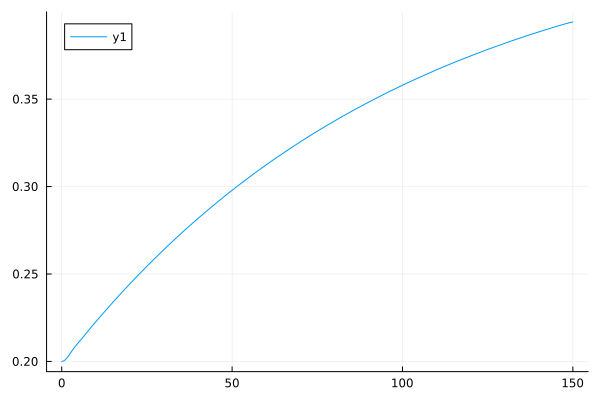

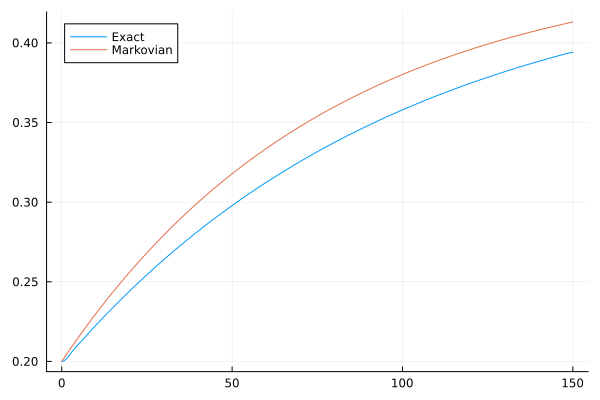

In [ ]:

bath = chain_mapping.BathParameters(Γ = 0.01,β = 1.0,μ = 0,D = 1.0,N = 150,spectral_function="smoothed box")

system = chain_mapping.RingParameters(B =0.1,J = 0.1,N_ring = 1,occupations=[0.2,0.8,0.1], compute_maps_bool = true)

symmetry_subspace = "Full"#"Number conserving"

Hsingle,initial_correlation_matrix,sys_anc_inds,system_inds,ancilla_inds = chain_mapping.build_thermofield_ring_model(bath,system);

#evolution parameters
δt = 0.05
T = 150
times = range(δt,stop=T,step=δt)
site = 1

println("Correlation matrix propagator")
corrs = map_calculations.propagate_correlations(initial_correlation_matrix,Hsingle,times)
den = [corr[site,site] for corr in corrs]
display(Plots.plot(times,real.(den)))

println("Markovian evolution")
dissipation_ind = 1
L_markovian = map_calculations.fermionic_spin_ring_lindblad(bath,system,dissipation_ind)
ρi = map_calculations.calculate_ρ_from_correlation_matrix(initial_correlation_matrix,system_inds; eps=1e-14)
ρi = map_calculations.vectorise_mat(ρi)
ρ_markovian_vec = map_calculations.markovian_evolution(L_markovian,ρi,times)
den_markovian = [tr(map_calculations.number_operator(site,system.N_ring)*map_calculations.unvectorise_ρ(ρ,true)) for ρ in ρ_markovian_vec]

plot(times,real.(den),label="Exact")
display(plot!(times,real.(den_markovian),label="Markovian"))

if system.compute_maps_bool

    Λi = map_calculations.calculate_Λ_from_correlation_matrix(initial_correlation_matrix,1:2*system.N_ring,system.N_ring+1:2*system.N_ring;symmetry_subspace="Full")
    Λ_vec,L_vec = map_calculations.compute_maps(corrs,δt,sys_anc_inds,ancilla_inds;symmetry_subspace=symmetry_subspace)
    [Λ_vec[i] = Λi*Λ_vec[i] for i=1:length(Λ_vec)]
    
    spectra_Λ,spectra_L = map_calculations.compute_spectra(Λ_vec,L_vec)
    propagator_steadystates  = [map_calculations.NESS_extraction(L,"L",system.N_ring;symmetry_subspace=symmetry_subspace) for L in L_vec]
    map_steadystates = [map_calculations.NESS_extraction(Λ,"Λ",system.N_ring;symmetry_subspace=symmetry_subspace) for Λ in Λ_vec]

    dLdt = map_calculations.differentiate(L_vec,δt)

    #map check
    ρi = map_calculations.calculate_ρ_from_correlation_matrix(initial_correlation_matrix,system_inds; eps=1e-14)
    ρ_evolved = map_calculations.calculate_ρ_from_correlation_matrix(corrs[end],system_inds; eps=1e-14)
    if symmetry_subspace =="Number conserving"
        @show(norm(map_calculations.expand_Λ(Λ_vec[end],system.N_ring)*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))
    else
        @show(norm(Λ_vec[end]*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))

    end
    display(Plots.plot(times,real.(spectra_Λ),label=false,title="Map spectra"))
    display(Plots.plot(times[2:end-1],real.(spectra_L),ms=0.1,label=false,title="propagator spectra"))

    display(plot(times[3:end-2],norm.(dLdt),label="|dL/dt|"))
end

In [5]:
eigen(L_vec[1500]).values

4-element Vector{ComplexF64}:
 -0.010031549068113158 - 2.8834157762330266e-17im
 -0.005015521891702318 - 0.20067244900054376im
 -0.005015521891701356 + 0.20067244900054246im
 4.454986726742938e-16 + 1.3747962031040827e-17im

In [6]:
eigen(L_markovian).values

4-element Vector{ComplexF64}:
 -0.012732395447351628 + 0.0im
 -0.006366197723675814 - 0.2im
 -0.006366197723675814 + 0.2im
  9.75781955236954e-19 + 0.0im

In [38]:
eigen(L_markovian).values

64-element Vector{ComplexF64}:
   -0.06366197723675819 - 1.0130785099704553e-15im
     -0.063661977236758 - 4.172009959724221e-16im
   -0.06366197723675772 - 7.815445443759192e-16im
   -0.06366197723675734 + 4.788920995868473e-16im
   -0.05305171405951988 + 5.999962473518332im
   -0.05305171405951942 + 5.999962473518333im
  -0.053051714059519355 - 5.999962473518333im
  -0.053051714059517696 - 5.99996247351833im
   -0.05305171405951735 - 5.99996247351835im
  -0.053051714059517266 + 5.999962473518332im
                        ⋮
   -0.01061026317724223 + 5.999962473518329im
  -0.010610263177242207 - 5.999962473518343im
  -0.010610263177241123 - 5.999962473518324im
  -0.010610263177240854 + 5.999962473518337im
  -0.010610263177236883 - 5.999962473518322im
  9.543321360324107e-17 - 9.447875906707723e-16im
 1.2953826058957972e-16 + 1.5191160388148854e-15im
  4.780424148196011e-16 + 8.445754964430578e-16im
   9.09521524436103e-16 - 8.658800040029893e-16im

In [5]:

# anim = @animate for i=1:length(times)
#     Plots.scatter(real.(spectra_Λ[i,:]),imag.(spectra_Λ[i,:]),
#     xlim=(-1,1),ylim=(-1,1),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"map spectrum1.gif")


# anim = @animate for i=1:length(times)-2
#     Plots.scatter(real.(spectra_L[i,:]),imag.(spectra_L[i,:]),
#     xlim=(-0.25,0.02),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"propagator spectrum2.gif")